# Conv1D-LSTM Autoencoder with SWaT A7 June 2020

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
clean_folder = Path("../data/clean/SWaT.A7_June2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

print("Archivos encontrados:", len(file_paths))
for fp in file_paths:
    print(fp)

Archivos encontrados: 4
..\data\clean\SWaT.A7_June2020_clean\22June2020_1.csv
..\data\clean\SWaT.A7_June2020_clean\22June2020_2.csv
..\data\clean\SWaT.A7_June2020_clean\29June2020_1.csv
..\data\clean\SWaT.A7_June2020_clean\29June2020_2.csv


In [3]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

In [4]:
files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

print("Número de archivos cargados:", len(files))
for name, df in files.items():
    print(name, df.shape)

Número de archivos cargados: 4
22June2020_1 (14400, 61)
22June2020_2 (3600, 61)
29June2020_1 (7201, 61)
29June2020_2 (7201, 61)


In [5]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

Número de columnas comunes: 61


In [6]:
files = {name: df[common_cols].copy() for name, df in files.items()}

base_columns = next(iter(files.values())).columns.tolist()

for name, df in files.items():
    assert df.columns.tolist() == base_columns, f"Columnas distintas en archivo {name}"

print("Todos los archivos tienen las mismas columnas.")
print("Número de variables:", len(base_columns))

Todos los archivos tienen las mismas columnas.
Número de variables: 61


## Reproducibilidad

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

## Identificación de variables

In [8]:
sample_df = next(iter(files.values()))
all_cols = sample_df.columns.tolist()

timestamp_cols = [c for c in all_cols if c == "t_stamp"]
pv_cols = [c for c in all_cols if c.endswith(".Pv")]
status_cols = [c for c in all_cols if c.endswith(".Status")]
state_cols = [c for c in all_cols if c.startswith("P") and c.endswith("_STATE")]

classified_cols = set(timestamp_cols + pv_cols + status_cols + state_cols)
other_cols = [c for c in all_cols if c not in classified_cols]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print("Resumen de variables detectadas")
print(f"Timestamp: {len(timestamp_cols)}")
print(f"Sensores continuos (.Pv): {len(pv_cols)}")
print(f"Actuadores discretos (.Status): {len(status_cols)}")
print(f"Estados discretos (_STATE): {len(state_cols)}")
print(f"Otras columnas no clasificadas: {len(other_cols)}")

Resumen de variables detectadas
Timestamp: 1
Sensores continuos (.Pv): 25
Actuadores discretos (.Status): 29
Estados discretos (_STATE): 6
Otras columnas no clasificadas: 0


In [9]:
print("\n--- Sensores continuos (.Pv) ---")
print(pv_cols)

print("\n--- Actuadores discretos (.Status) ---")
print(status_cols)

print("\n--- Estados discretos (_STATE) ---")
print(state_cols)

print("\nVariables continuas a escalar:", len(continuous_cols))
print("Variables discretas a escalar acotadamente:", len(discrete_cols))


--- Sensores continuos (.Pv) ---
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']

--- Actuadores discretos (.Status) ---
['MV101.Status', 'MV201.Status', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'P101.Status', 'P102.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P301.Status', 'P302.Status', 'P401.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P501.Status', 'P502.Status', 'P601.Status', 'P602.Status', 'UV401.Status']

--- Estados discretos (_STATE) ---
['P1_STATE', 'P2_STATE', 'P3_STATE', 'P4_STATE', 'P5_STATE', 'P6_STATE']

Variables continuas a escalar: 25
Variable

In [10]:
summary_rows = []

for name, df in files.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": len(df.columns),
        "start_time": df["t_stamp"].min(),
        "end_time": df["t_stamp"].max(),
        "missing_total": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7201,61,2020-06-29 13:30:00,2020-06-29 15:30:00.000,60


In [11]:
for name, df in files.items():
    print(f"\n===== {name} =====")
    print("NaN en Pv:")
    print(df[pv_cols].isna().sum().sort_values(ascending=False).head(10))

    print("\nNaN en Status/STATE:")
    print(df[status_cols + state_cols].isna().sum().sort_values(ascending=False).head(10))


===== 22June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 22June2020_2 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 29June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
A

## Visualización de sensores clave

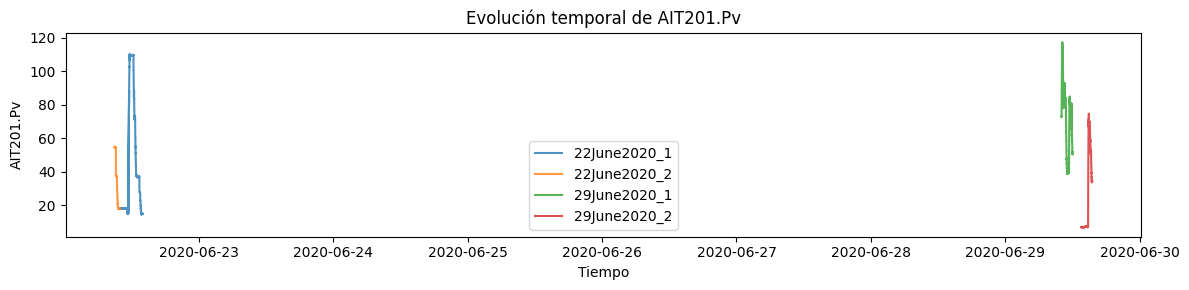

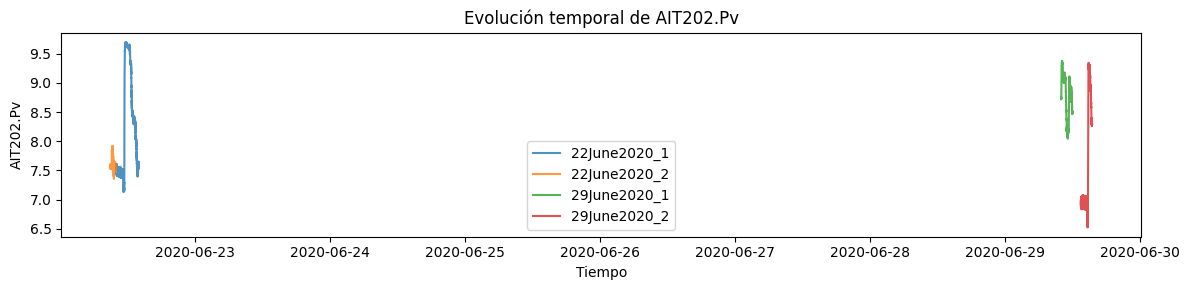

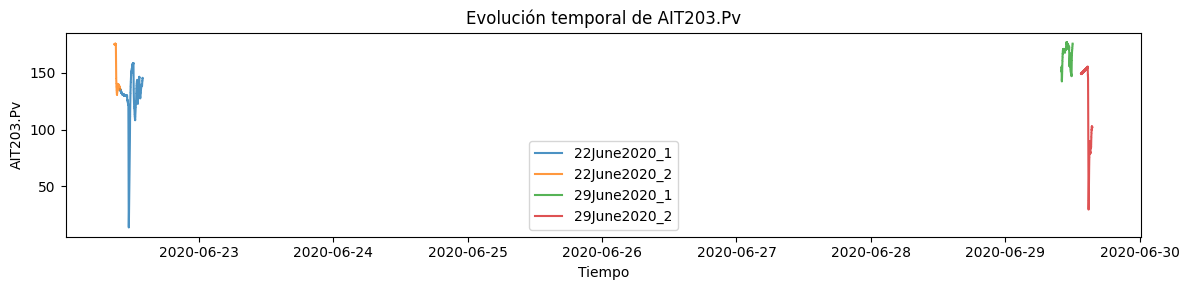

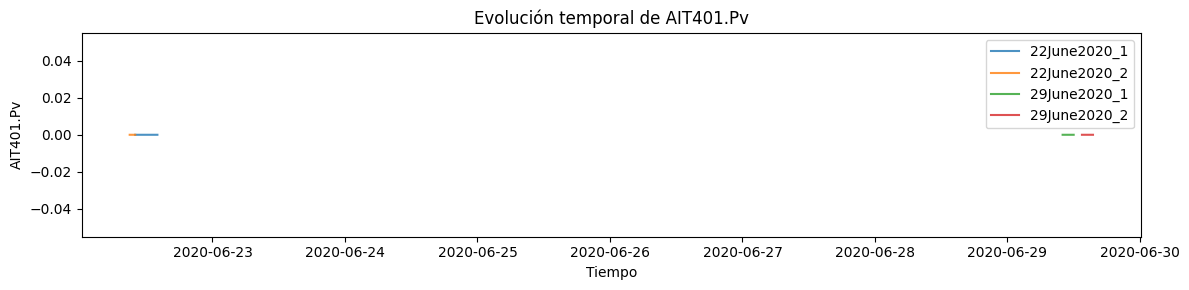

In [12]:
example_pv = ["AIT201.Pv", "AIT202.Pv", "AIT203.Pv", "AIT401.Pv"]

for col in example_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        plt.plot(df["t_stamp"], df[col], label=name, alpha=0.8)
    plt.title(f"Evolución temporal de {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Visualización por indice de muestra

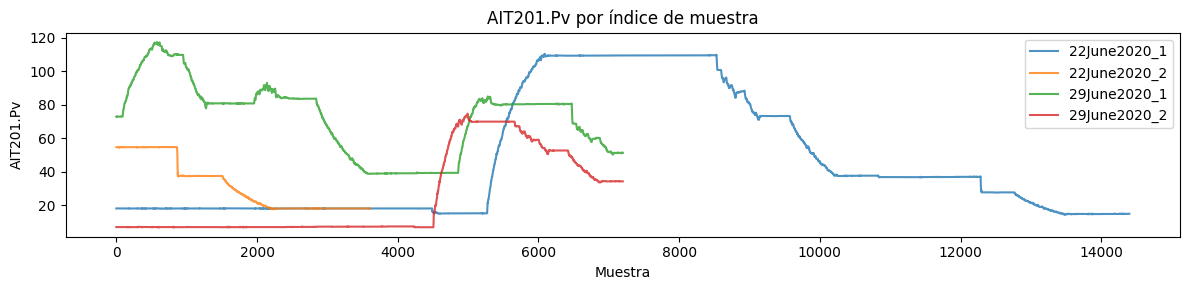

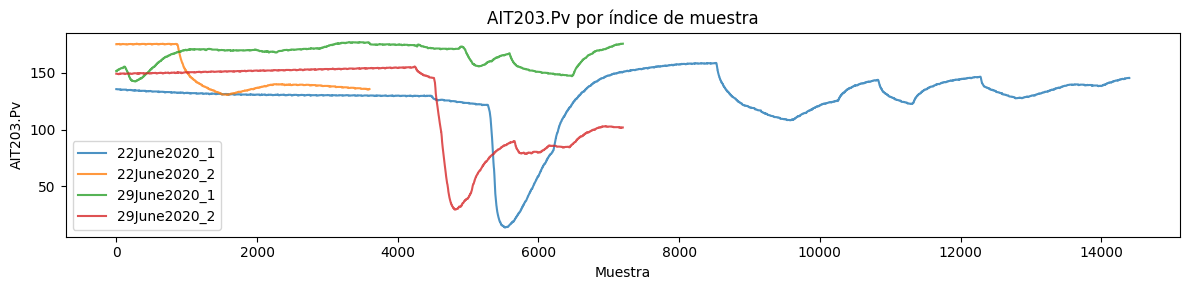

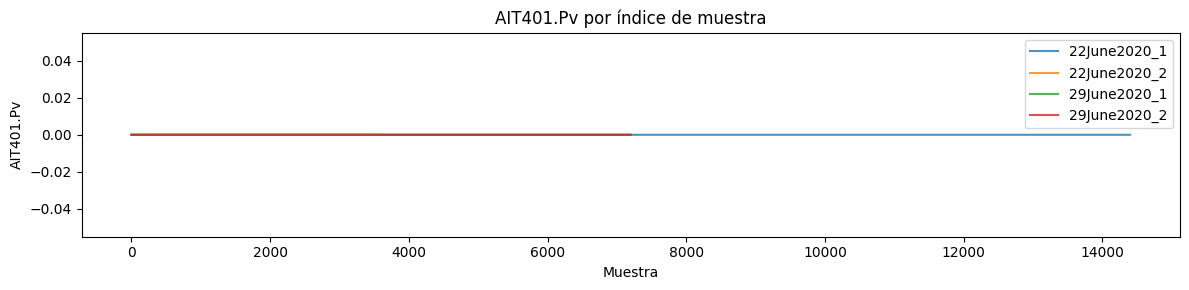

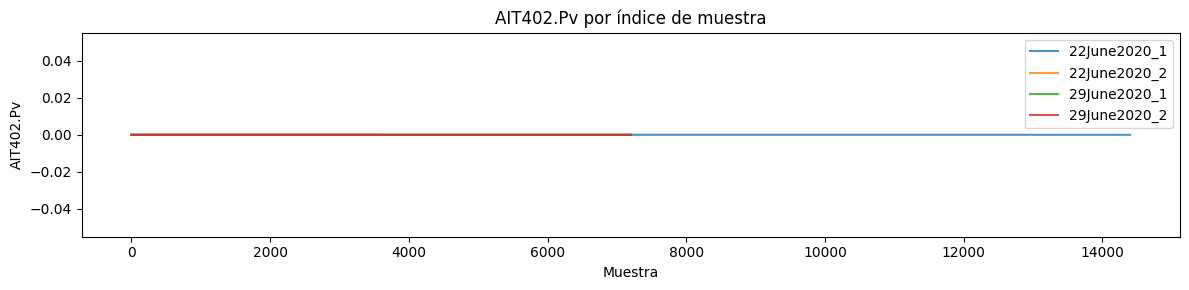

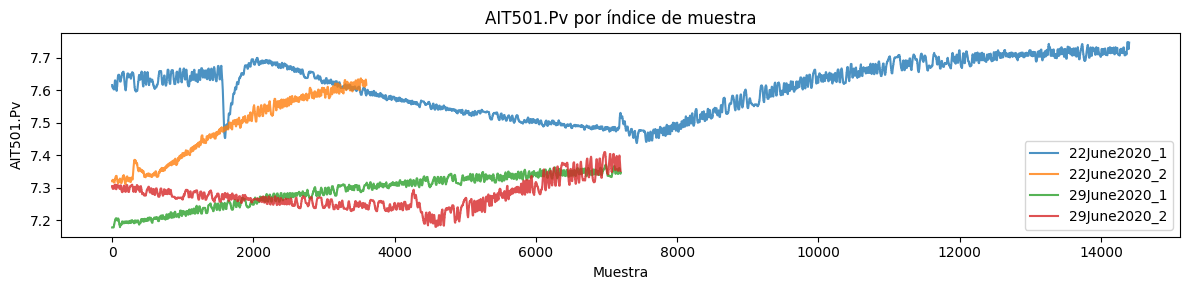

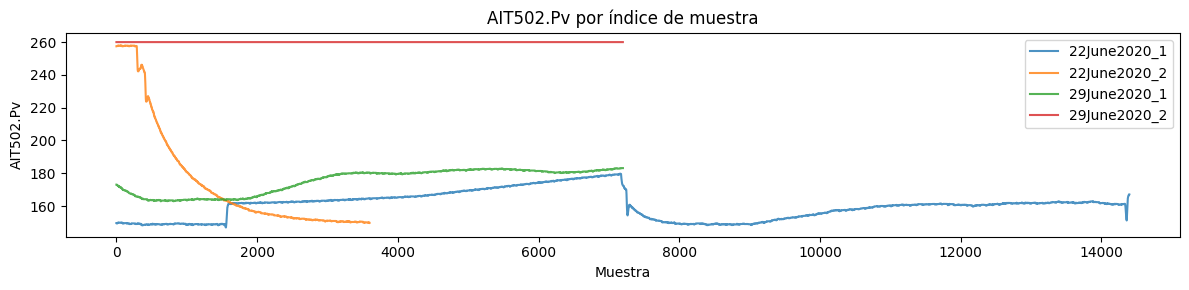

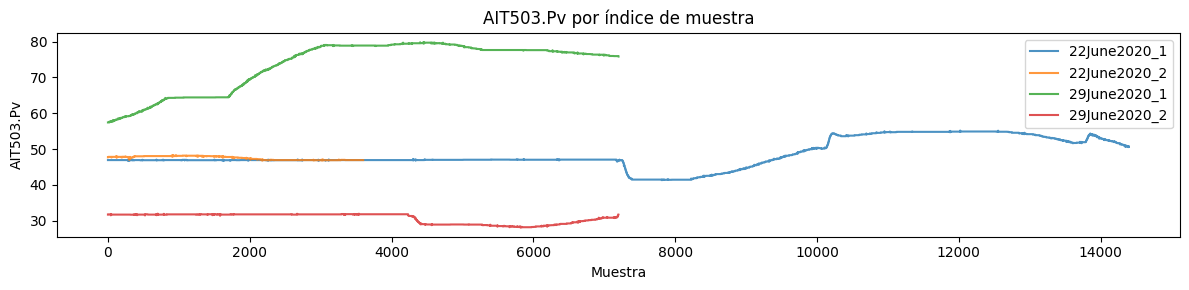

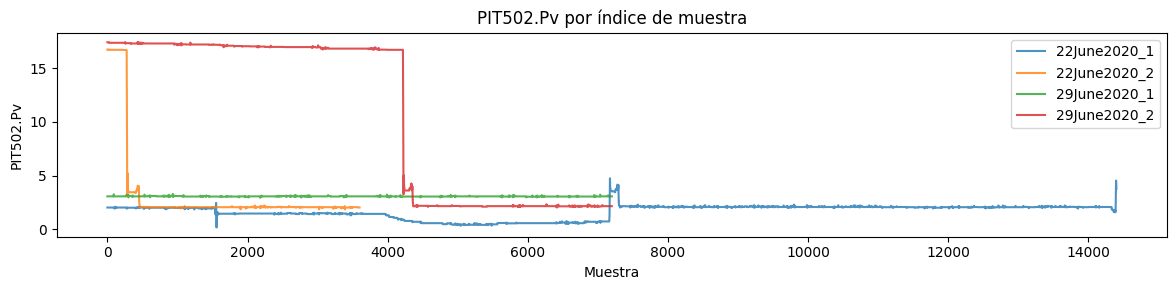

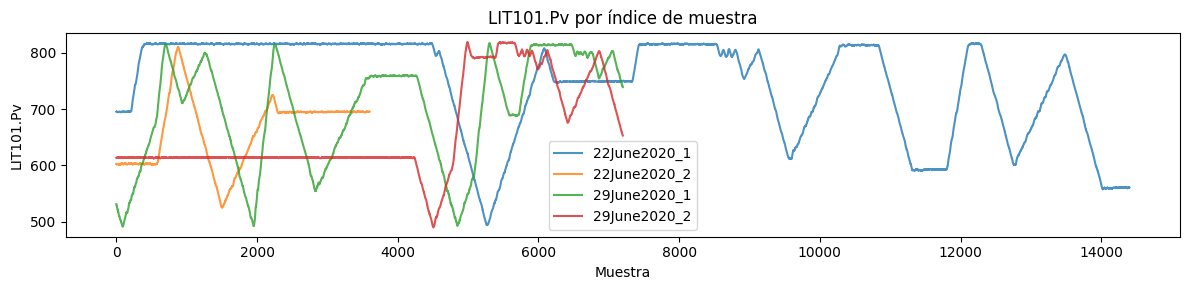

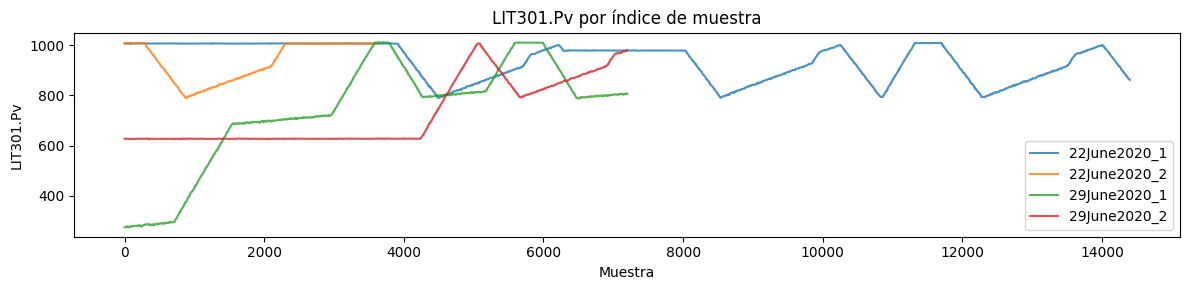

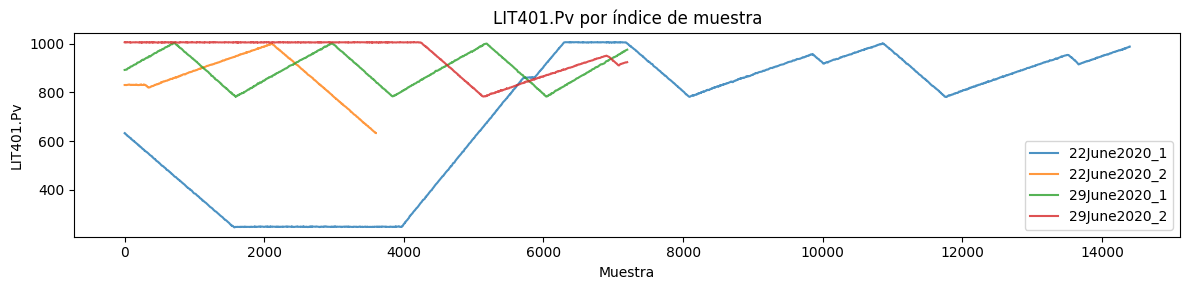

In [13]:
key_pv = [
    "AIT201.Pv", "AIT203.Pv", "AIT401.Pv", "AIT402.Pv",
    "AIT501.Pv", "AIT502.Pv", "AIT503.Pv",
    "PIT502.Pv", "LIT101.Pv", "LIT301.Pv", "LIT401.Pv"
]

for col in key_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        if col in df.columns:
            x = np.arange(len(df))
            plt.plot(x, df[col], label=name, alpha=0.8)
    plt.title(f"{col} por índice de muestra")
    plt.xlabel("Muestra")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Perfilamiento por columna

In [14]:
profile_rows = []

for col in feature_cols:
    col_type = (
        "continuous" if col in continuous_cols
        else "discrete"
    )

    values = pd.concat([df[col] for df in files.values()], axis=0)

    profile_rows.append({
        "feature": col,
        "type": col_type,
        "n_unique": values.nunique(dropna=True),
        "missing": values.isna().sum(),
        "is_constant": values.nunique(dropna=True) <= 1,
        "min": values.min() if col_type == "continuous" else None,
        "max": values.max() if col_type == "continuous" else None,
        "mean": values.mean() if col_type == "continuous" else None,
        "std": values.std() if col_type == "continuous" else None
    })

profile_df = pd.DataFrame(profile_rows).sort_values(["type", "feature"])
profile_df

,feature,type,n_unique,missing,is_constant,min,max,mean,std
0,AIT201.Pv,continuous,1817,1,False,6.729044,117.405792,4.538645e+01,3.333202e+01
1,AIT202.Pv,continuous,5838,1,False,6.525122,9.695784,8.194726e+00,8.985818e-01
2,AIT203.Pv,continuous,2954,1,False,13.919508,177.108429,1.379827e+02,2.993334e+01
3,AIT401.Pv,continuous,1,1,True,0.000000,0.000000,0.000000e+00,0.000000e+00
4,AIT402.Pv,continuous,1,1,True,0.000000,0.000000,0.000000e+00,0.000000e+00
5,AIT501.Pv,continuous,1369,1,False,7.177519,7.747885,7.449547e+00,1.689963e-01
6,AIT502.Pv,continuous,1282,1,False,146.936676,260.000000,1.876159e+02,4.132093e+01
7,AIT503.Pv,continuous,613,1,False,28.101768,79.851320,4.998782e+01,1.498397e+01
8,AIT504.Pv,continuous,358,1,False,0.038452,101.473984,2.353729e+00,4.103129e+00
9,DPIT301.Pv,continuous,1125,1,False,0.016006,19.191370,9.576453e+00,6.394101e+00


## Columnas constantes

In [15]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()
print("Columnas constantes:", constant_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status']


In [16]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols)

pv_cols = [c for c in pv_cols if c not in constant_cols]
status_cols = [c for c in status_cols if c not in constant_cols]
state_cols = [c for c in state_cols if c not in constant_cols]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print("Features después de eliminar constantes:", len(feature_cols))
print("Continuas:", len(continuous_cols))
print("Discretas:", len(discrete_cols))

Features después de eliminar constantes: 49
Continuas: 23
Discretas: 26


## Recorte de warm-up

In [17]:
WARMUP = 120

files = {
    name: df.iloc[WARMUP:].reset_index(drop=True)
    for name, df in files.items()
}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14280, 50)
22June2020_2 (3480, 50)
29June2020_1 (7081, 50)
29June2020_2 (7081, 50)


In [18]:
for name, df in files.items():
    missing = df[feature_cols].isna().sum().sum()
    print(name, "missing total:", missing)

22June2020_1 missing total: 0
22June2020_2 missing total: 0
29June2020_1 missing total: 0
29June2020_2 missing total: 49


## Separar timestamp y features

In [19]:
dfs = []

for name, df in files.items():
    dfs.append(df[feature_cols].copy())

print("Número de dataframes listos para modelado:", len(dfs))
print("Shape archivo 1:", dfs[0].shape)

Número de dataframes listos para modelado: 4
Shape archivo 1: (14280, 49)


## Partición temporal

In [20]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [21]:
train_parts = []
val_parts = []
test_parts = []

for i, df_i in enumerate(dfs):
    train_i, val_i, test_i = temporal_split(df_i, train_ratio=0.6, val_ratio=0.2)

    train_parts.append(train_i)
    val_parts.append(val_i)
    test_parts.append(test_i)

    print(f"Archivo {i+1}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
val_df   = pd.concat(val_parts, axis=0).reset_index(drop=True)
test_df  = pd.concat(test_parts, axis=0).reset_index(drop=True)

print("\nShapes concatenados:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Archivo 1:
  train: (8568, 49)
  val:   (2856, 49)
  test:  (2856, 49)
Archivo 2:
  train: (2088, 49)
  val:   (696, 49)
  test:  (696, 49)
Archivo 3:
  train: (4248, 49)
  val:   (1416, 49)
  test:  (1417, 49)
Archivo 4:
  train: (4248, 49)
  val:   (1416, 49)
  test:  (1417, 49)

Shapes concatenados:
Train: (19152, 49)
Val:   (6384, 49)
Test:  (6386, 49)


## Escalado de variables

In [22]:
scaler_cont = StandardScaler()

train_cont = pd.DataFrame(
    scaler_cont.fit_transform(train_df[continuous_cols]),
    columns=continuous_cols
)

val_cont = pd.DataFrame(
    scaler_cont.transform(val_df[continuous_cols]),
    columns=continuous_cols
)

test_cont = pd.DataFrame(
    scaler_cont.transform(test_df[continuous_cols]),
    columns=continuous_cols
)

In [23]:
train_disc = train_df[discrete_cols].copy()
val_disc   = val_df[discrete_cols].copy()
test_disc  = test_df[discrete_cols].copy()

disc_max = train_disc.max().replace(0, 1)

train_disc_scaled = train_disc / disc_max
val_disc_scaled   = val_disc / disc_max
test_disc_scaled  = test_disc / disc_max

In [24]:
train_scaled = pd.concat(
    [train_cont.reset_index(drop=True), train_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

val_scaled = pd.concat(
    [val_cont.reset_index(drop=True), val_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

test_scaled = pd.concat(
    [test_cont.reset_index(drop=True), test_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

In [25]:
print("Continuous stats (train):")
print(train_scaled[continuous_cols].describe().loc[['mean', 'std']])

print("\nDiscrete stats (train):")
print(train_scaled[discrete_cols].describe().loc[['min', 'max']])

print("\nAny NaNs?")
print(train_scaled.isna().sum().sum())

Continuous stats (train):
         AIT201.Pv     AIT202.Pv     AIT203.Pv     AIT501.Pv     AIT502.Pv  \
mean -4.748824e-17 -1.567112e-15  1.234694e-15 -5.698588e-15 -4.748824e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         AIT503.Pv     AIT504.Pv    DPIT301.Pv     FIT101.Pv     FIT201.Pv  \
mean  2.374412e-17 -5.936030e-17 -1.068485e-16  2.374412e-17  9.497647e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      ...     FIT502.Pv     FIT503.Pv     FIT504.Pv     FIT601.Pv  \
mean  ... -7.123235e-17  5.936030e-17 -3.710018e-18 -2.968015e-18   
std   ...  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         LIT101.Pv     LIT301.Pv     LIT401.Pv     PIT501.Pv     PIT502.Pv  \
mean -1.424647e-16 -9.497647e-17  3.799059e-16 -2.136971e-16 -2.374412e-16   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      PIT503.Pv  
mean   0.000000  
std    1.000026  

[2 row

## Correlación de sensores continuos

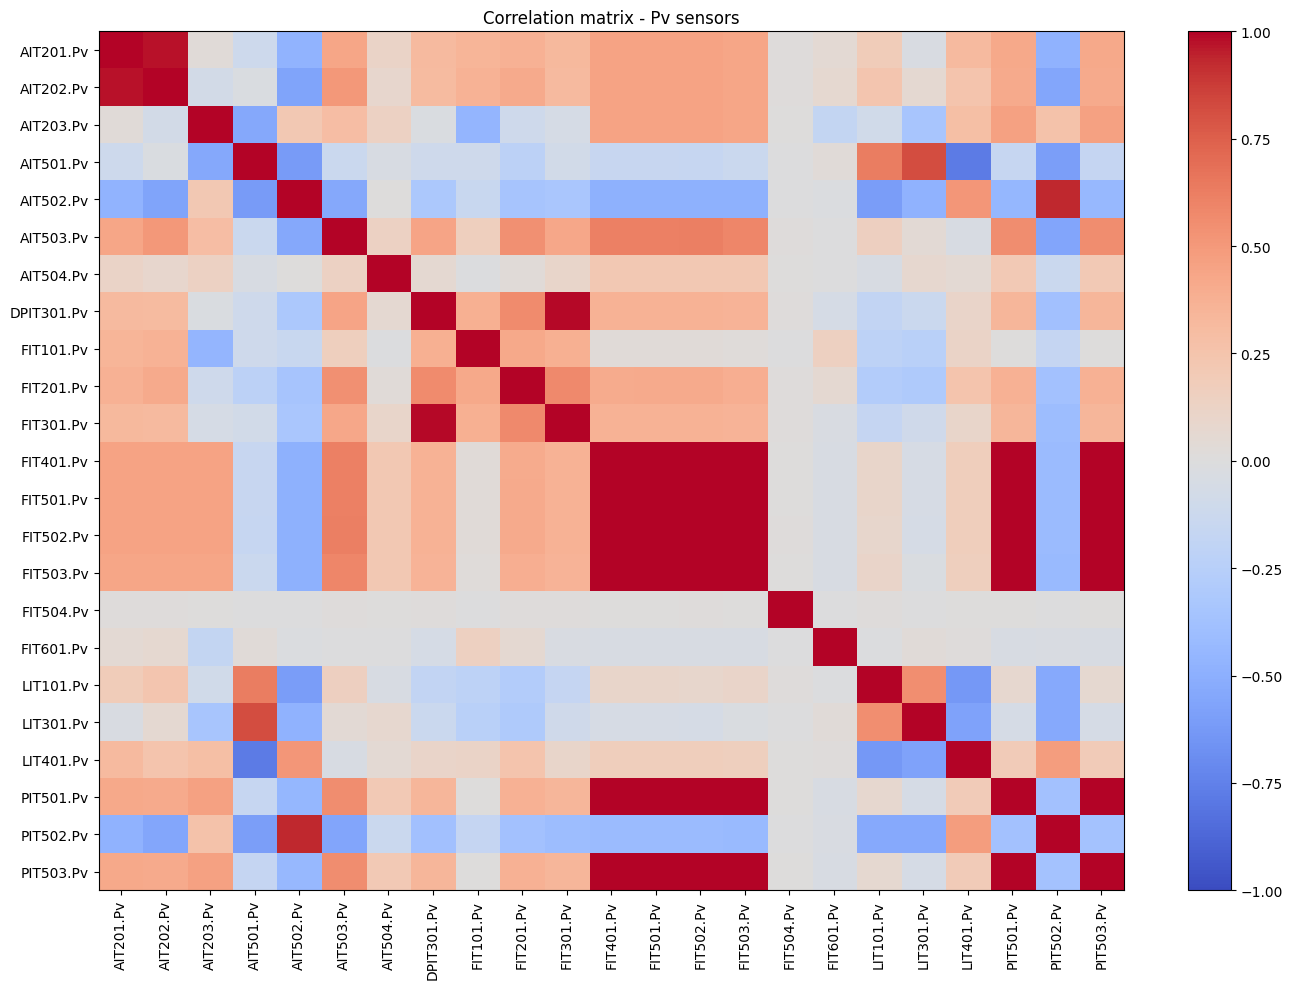

In [26]:
corr = train_df[continuous_cols].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar()
plt.xticks(range(len(continuous_cols)), continuous_cols, rotation=90)
plt.yticks(range(len(continuous_cols)), continuous_cols)
plt.title("Correlation matrix - Pv sensors")
plt.tight_layout()
plt.show()

In [27]:
high_corr_pairs = []

for i, col1 in enumerate(continuous_cols):
    for j, col2 in enumerate(continuous_cols):
        if j > i:
            val = corr.loc[col1, col2]
            if abs(val) >= 0.75:
                high_corr_pairs.append((col1, col2, val))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("Pares altamente correlacionados:")
for pair in high_corr_pairs[:30]:
    print(pair)

Pares altamente correlacionados:
('FIT401.Pv', 'FIT501.Pv', np.float64(0.9999909120713507))
('PIT501.Pv', 'PIT503.Pv', np.float64(0.9999707150925253))
('FIT401.Pv', 'FIT502.Pv', np.float64(0.9995717075329312))
('FIT501.Pv', 'FIT502.Pv', np.float64(0.9995546895426954))
('FIT401.Pv', 'FIT503.Pv', np.float64(0.9986610244604763))
('FIT501.Pv', 'FIT503.Pv', np.float64(0.9986266323390656))
('FIT503.Pv', 'PIT501.Pv', np.float64(0.9982122871360277))
('FIT503.Pv', 'PIT503.Pv', np.float64(0.9978325750584565))
('FIT502.Pv', 'FIT503.Pv', np.float64(0.9976296406871232))
('FIT401.Pv', 'PIT501.Pv', np.float64(0.9970883242654135))
('FIT501.Pv', 'PIT501.Pv', np.float64(0.9970344256699942))
('FIT401.Pv', 'PIT503.Pv', np.float64(0.996506613031625))
('FIT501.Pv', 'PIT503.Pv', np.float64(0.9964499713496913))
('FIT502.Pv', 'PIT501.Pv', np.float64(0.9961473874955706))
('FIT502.Pv', 'PIT503.Pv', np.float64(0.99548418917892))
('DPIT301.Pv', 'FIT301.Pv', np.float64(0.9861944003176474))
('AIT201.Pv', 'AIT202.Pv'

## Crear ventanas temporales

In [28]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        windows.append(data[i:i+window_size])
    return np.array(windows)

In [29]:
L = 60
stride = 5

train_windows = create_windows(train_scaled.values, window_size=L, stride=stride)
val_windows   = create_windows(val_scaled.values, window_size=L, stride=stride)
test_windows  = create_windows(test_scaled.values, window_size=L, stride=stride)

print("Train windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

Train windows: (3819, 60, 49)
Validation windows: (1265, 60, 49)
Test windows: (1266, 60, 49)


## Reorganizar para Conv1D-LSTM

In [30]:
X_train = np.transpose(train_windows, (0, 2, 1))
X_val   = np.transpose(val_windows, (0, 2, 1))
X_test  = np.transpose(test_windows, (0, 2, 1))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3819, 49, 60)
X_val: (1265, 49, 60)
X_test: (1266, 49, 60)


## Tensores y DataLoaders

In [31]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset   = TensorDataset(X_val_tensor)
test_dataset  = TensorDataset(X_test_tensor)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Modelo Conv1D-LSTM AC

In [32]:
class Conv1dLSTMAutoencoder(nn.Module):
    def __init__(self, input_channels, seq_len, latent_dim=64):
        super(Conv1dLSTMAutoencoder, self).__init__()

        self.input_channels = input_channels
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        # Encoder convolucional
        self.conv_encoder = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 60 -> 30

            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)    # 30 -> 15
        )

        # LSTM encoder
        self.lstm_encoder = nn.LSTM(
            input_size=32,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc_latent = nn.Linear(128, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 128)

        # LSTM decoder
        self.lstm_decoder = nn.LSTM(
            input_size=128,
            hidden_size=32,
            num_layers=1,
            batch_first=True
        )

        # Decoder convolucional
        self.deconv_decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 64, kernel_size=2, stride=2),   # 15 -> 30
            nn.ReLU(),
            nn.ConvTranspose1d(64, input_channels, kernel_size=2, stride=2)  # 30 -> 60
        )

    def forward(self, x):
        # x: (batch, channels, seq_len)
        z = self.conv_encoder(x)   # (batch, 32, 15)

        # para LSTM: (batch, seq, features)
        z = z.permute(0, 2, 1)     # (batch, 15, 32)

        _, (hidden, _) = self.lstm_encoder(z)
        hidden = hidden[-1]        # (batch, 128)

        latent = self.fc_latent(hidden)     # (batch, latent_dim)
        decoded = self.fc_decoder(latent)   # (batch, 128)

        decoded = decoded.unsqueeze(1).repeat(1, z.shape[1], 1)  # (batch, 15, 128)
        decoded, _ = self.lstm_decoder(decoded)                  # (batch, 15, 32)

        # volver a formato conv
        decoded = decoded.permute(0, 2, 1)   # (batch, 32, 15)

        x_hat = self.deconv_decoder(decoded) # (batch, channels, 60)
        return x_hat

In [33]:
input_channels = X_train.shape[1]
seq_len = X_train.shape[2]

model = Conv1dLSTMAutoencoder(
    input_channels=input_channels,
    seq_len=seq_len,
    latent_dim=64
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Input channels:", input_channels)
print("Sequence length:", seq_len)

Device: cpu
Input channels: 49
Sequence length: 60


## Función de pérdida y optimizador

In [34]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 30
loss_history = []
val_loss_history = []

## Entrenamiento

In [35]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x_val_batch = batch[0].to(device)
            x_val_hat = model(x_val_batch)
            val_loss = criterion(x_val_hat, x_val_batch)
            total_val_loss += val_loss.item()

    epoch_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_loss:.6f} - Val Loss: {epoch_val_loss:.6f}")

Epoch [1/30] - Train Loss: 0.713780 - Val Loss: 0.779485
Epoch [2/30] - Train Loss: 0.614550 - Val Loss: 0.583368
Epoch [3/30] - Train Loss: 0.522852 - Val Loss: 0.523710
Epoch [4/30] - Train Loss: 0.499547 - Val Loss: 0.500069
Epoch [5/30] - Train Loss: 0.484615 - Val Loss: 0.461135
Epoch [6/30] - Train Loss: 0.462061 - Val Loss: 0.429434
Epoch [7/30] - Train Loss: 0.417590 - Val Loss: 0.397168
Epoch [8/30] - Train Loss: 0.364838 - Val Loss: 0.376259
Epoch [9/30] - Train Loss: 0.327532 - Val Loss: 0.363106
Epoch [10/30] - Train Loss: 0.306336 - Val Loss: 0.358766
Epoch [11/30] - Train Loss: 0.289498 - Val Loss: 0.357510
Epoch [12/30] - Train Loss: 0.275468 - Val Loss: 0.355796
Epoch [13/30] - Train Loss: 0.263547 - Val Loss: 0.356496
Epoch [14/30] - Train Loss: 0.252114 - Val Loss: 0.354513
Epoch [15/30] - Train Loss: 0.242293 - Val Loss: 0.355421
Epoch [16/30] - Train Loss: 0.236223 - Val Loss: 0.352300
Epoch [17/30] - Train Loss: 0.229859 - Val Loss: 0.349247
Epoch [18/30] - Train L

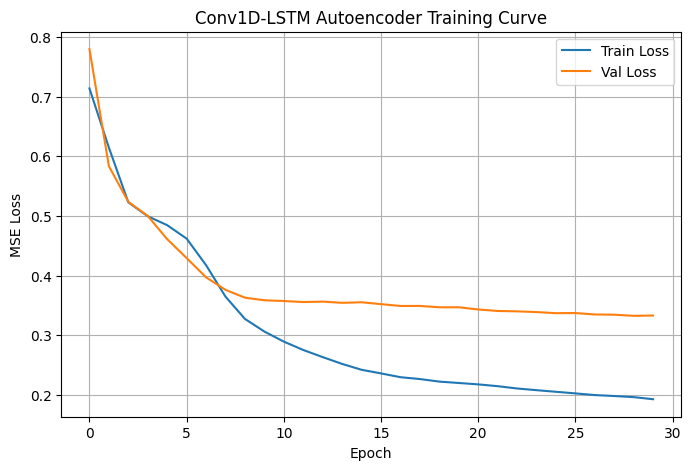

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conv1D-LSTM Autoencoder Training Curve")
plt.grid(True)
plt.legend()
plt.show()

## Errores de reconstrucción en validación

In [37]:
model.eval()

with torch.no_grad():
    x_val = X_val_tensor.to(device)
    x_val_hat = model(x_val)

    val_error = torch.mean((x_val - x_val_hat) ** 2, dim=(1, 2))
    val_reconstruction_errors = val_error.cpu().numpy()

print("Validation errors shape:", val_reconstruction_errors.shape)
print("Validation error mean:", val_reconstruction_errors.mean())
print("Validation error std:", val_reconstruction_errors.std())

Validation errors shape: (1265,)
Validation error mean: 0.3321173
Validation error std: 0.6062807


## Errores de reconstrucción en test

In [38]:
with torch.no_grad():
    x_test = X_test_tensor.to(device)
    x_test_hat = model(x_test)

    test_error = torch.mean((x_test - x_test_hat) ** 2, dim=(1, 2))
    test_reconstruction_errors = test_error.cpu().numpy()

print("Test errors shape:", test_reconstruction_errors.shape)
print("Test error mean:", test_reconstruction_errors.mean())
print("Test error std:", test_reconstruction_errors.std())

Test errors shape: (1266,)
Test error mean: 0.3426142
Test error std: 0.8162981


## Histograma de errores

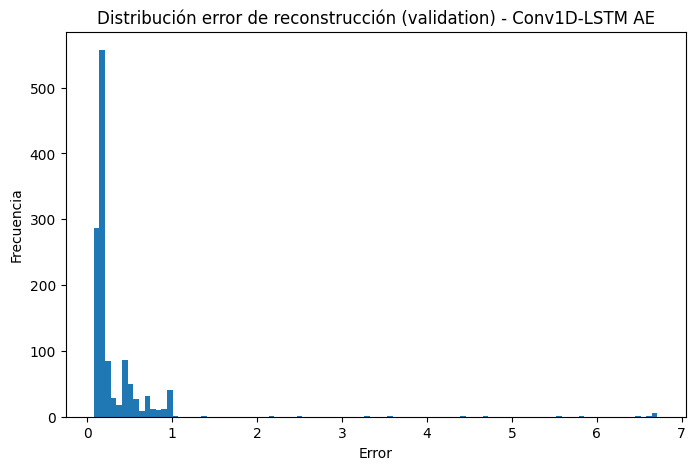

In [39]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción (validation) - Conv1D-LSTM AE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

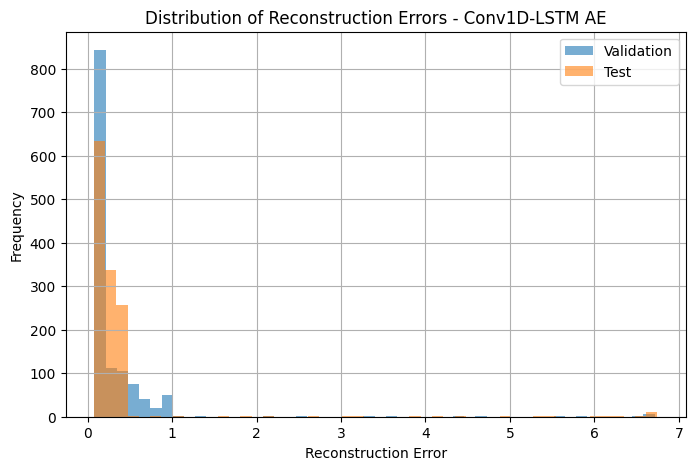

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(val_reconstruction_errors, bins=50, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=50, alpha=0.6, label="Test")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors - Conv1D-LSTM AE")
plt.legend()
plt.grid(True)
plt.show()

## Umbrales

In [41]:
percentiles = [90, 95, 97.5, 99, 99.5]

tau_dict = {
    p: np.percentile(val_reconstruction_errors, p)
    for p in percentiles
}

tau_df = pd.DataFrame({
    "percentile": list(tau_dict.keys()),
    "tau": list(tau_dict.values())
})

tau_df

,percentile,tau
0,90.0,0.629016
1,95.0,0.898901
2,97.5,0.973311
3,99.0,2.772235
4,99.5,6.279789


## FAR en validación y test

In [42]:
far_rows = []

for p, tau in tau_dict.items():
    far_val = np.mean(val_reconstruction_errors > tau)
    far_test = np.mean(test_reconstruction_errors > tau)

    far_rows.append({
        "percentile": p,
        "tau": tau,
        "FAR_val": far_val,
        "FAR_test": far_test,
        "FAR_val_pct": round(far_val * 100, 2),
        "FAR_test_pct": round(far_test * 100, 2)
    })

far_df = pd.DataFrame(far_rows)
far_df

,percentile,tau,FAR_val,FAR_test,FAR_val_pct,FAR_test_pct
0,90.0,0.629016,0.100395,0.026856,10.04,2.69
1,95.0,0.898901,0.050593,0.026066,5.06,2.61
2,97.5,0.973311,0.025296,0.026066,2.53,2.61
3,99.0,2.772235,0.010277,0.020537,1.03,2.05
4,99.5,6.279789,0.005534,0.011058,0.55,1.11


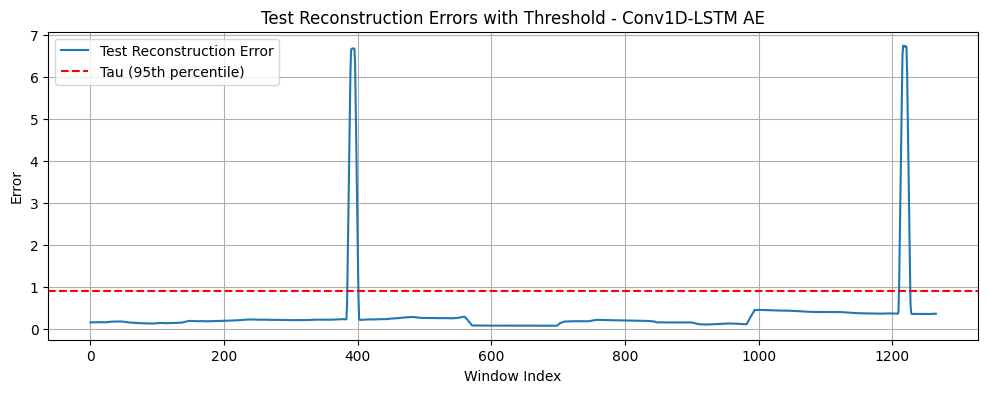

In [43]:
threshold = tau_dict[95]

plt.figure(figsize=(12, 4))
plt.plot(test_reconstruction_errors, label="Test Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Tau (95th percentile)")
plt.xlabel("Window Index")
plt.ylabel("Error")
plt.title("Test Reconstruction Errors with Threshold - Conv1D-LSTM AE")
plt.legend()
plt.grid(True)
plt.show()

## Guardado de artefactos

In [44]:
import os
import json
import joblib
import pandas as pd
from pathlib import Path
import torch

# =========================
# Configurar nombre del modelo
# =========================
MODEL_NAME = "conv1d_lstm_ae"   # cambiar según notebook: lstm_ae, conv1d_lstm_ae

# =========================
# Crear carpetas
# =========================
base_model_dir = Path(f"../models/detectors/{MODEL_NAME}")
base_model_dir.mkdir(parents=True, exist_ok=True)

scaler_dir = Path("../artifacts/scalers")
scaler_dir.mkdir(parents=True, exist_ok=True)

metadata_dir = Path("../artifacts/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

metrics_dir = Path("../artifacts/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Guardar pesos del modelo
# =========================
torch.save(model.state_dict(), base_model_dir / "model_state.pt")

# =========================
# Guardar escaladores
# =========================
joblib.dump(scaler_cont, scaler_dir / f"{MODEL_NAME}_scaler_cont.pkl")
joblib.dump(disc_max, scaler_dir / f"{MODEL_NAME}_disc_max.pkl")

# =========================
# Guardar configuración
# =========================
config = {
    "model_name": MODEL_NAME,
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": L,
    "stride": stride,
    "warmup": WARMUP,
    "seed": SEED,
    "epochs": epochs,
    "loss_function": str(criterion),
    "optimizer": optimizer.__class__.__name__,
    "learning_rate": optimizer.param_groups[0]["lr"],
    "train_shape": list(train_df.shape),
    "val_shape": list(val_df.shape),
    "test_shape": list(test_df.shape),
    "train_windows_shape": list(train_windows.shape),
    "val_windows_shape": list(val_windows.shape),
    "test_windows_shape": list(test_windows.shape),
}

with open(base_model_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# =========================
# Guardar taus
# =========================
tau_dict_serializable = {str(k): float(v) for k, v in tau_dict.items()}

with open(base_model_dir / "tau_dict.json", "w") as f:
    json.dump(tau_dict_serializable, f, indent=4)

# =========================
# Guardar métricas
# =========================
if "far_df" in globals():
    far_df.to_csv(base_model_dir / "metrics.csv", index=False)

# También guardar en carpeta general si quieres
if "far_df" in globals():
    far_df.to_csv(metrics_dir / f"{MODEL_NAME}_far.csv", index=False)

print(f"Artefactos guardados correctamente para {MODEL_NAME}")
print(f"Ruta: {base_model_dir.resolve()}")

Artefactos guardados correctamente para conv1d_lstm_ae
Ruta: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_lstm_ae
